# Relación entre el nivel educativo y los ingresos laborales en México

**ENIGH 2024 (INEGI, serie Nueva Construcción)**

Proyecto de práctica: análisis descriptivo y econométrico de la relación educación-ingresos.  
Autora: Sayde Abigail Canche Quintana

## 1. Definición de la investigación

**Pregunta:** ¿Cuál es la relación entre el nivel educativo y los ingresos laborales, considerando características como edad, sexo y horas trabajadas?

**Hipótesis:**
- H1: a mayor nivel educativo, mayor ingreso laboral.
- H2: la brecha de ingresos entre hombres y mujeres persiste aun controlando por educación, edad y horas trabajadas.
- H3: el perfil ingreso-edad es cóncavo (crece y luego decrece).

**Objetivo:** estimar el rendimiento de la educación mediante la ecuación de Mincer con controles de edad, sexo y horas trabajadas, usando los factores de expansión de la encuesta.

## 2. Elección de la fuente: ENOE vs ENIGH

| Criterio | ENOE | ENIGH |
|---|---|---|
| Objetivo | Dinámica del mercado laboral | Distribución de ingresos y gastos |
| Periodicidad | Trimestral | Bienal |
| Ingresos | Solo laborales, detalle limitado | Detallados por concepto (sueldos, horas extras, aguinaldo, negocios...) |
| Educación | Nivel e años de escolaridad | Nivel y grado aprobado de cada integrante |
| Uso típico | Empleo | Pobreza, distribución del ingreso, Mincer |

**Elección: ENIGH 2024** por su detalle de ingresos laborales por concepto, la educación de cada integrante del hogar y los factores de expansión. Archivos usados: `poblacion.csv`, `trabajos.csv`, `ingresos.csv` y `concentradohogar.csv`.

## 3. Descarga y limpieza de datos

In [1]:
import sys
print("Python:", sys.executable)
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import statsmodels.api as sm
except ModuleNotFoundError as e:
    raise RuntimeError(
        f"Falta el paquete {e.name}. Ejecuta 'pip install -r requirements.txt' "
        "y verifica que el kernel del notebook sea 'Python 3.12 (ENIGH)'."
    ) from e
print("Paquetes OK: numpy", np.__version__, "| pandas", pd.__version__, "| statsmodels", sm.__version__)

Python: C:\Users\SEMAIG-424\AppData\Local\Programs\Python\Python312\python.exe


Paquetes OK: numpy 2.5.2 | pandas 3.0.5 | statsmodels 0.14.6


In [2]:
import os
if os.path.basename(os.getcwd()) == "notebook":
    os.chdir("..")
if not os.path.exists("salida/base_ocupados_limpia.csv"):
    print("Descargando microdatos...")
    !python descarga_datos.py
    print("Limpiando datos...")
    !python limpieza.py
else:
    print("La base limpia ya existe en salida/.")

La base limpia ya existe en salida/.


In [3]:
base = pd.read_csv("salida/base_ocupados_limpia.csv", low_memory=False)
base = base.copy()
base["ln_ing_men"] = np.log(base["ing_lab_men"].clip(lower=1))
base["ln_hrs"] = np.log(base["hrs_sem"].clip(lower=1))
base["sexo_etq"] = base["sexo"].map({1: "Hombre", 2: "Mujer"})
print(f"Ocupados 14+ en la muestra: {len(base):,}")
print(f"Población expandida: {base['factor'].sum():,.0f}")
base[["sexo_etq", "edad", "escolaridad", "hrs_sem", "ing_lab_men", "factor"]].head()

Ocupados 14+ en la muestra: 149,276
Población expandida: 63,675,057


,sexo_etq,edad,escolaridad,hrs_sem,ing_lab_men,factor
0,Hombre,32,9.0,48.0,24180.0,207
1,Mujer,24,12.0,45.0,10000.0,207
2,Hombre,48,15.0,48.0,16000.0,207
3,Hombre,22,16.0,48.0,10000.0,207
4,Mujer,60,9.0,30.0,4000.0,207


## 4. Análisis descriptivo (ponderado por factor de expansión)

Perfil de la población ocupada y distribución del ingreso por nivel educativo y sexo.

In [4]:
def media_pond(g):
    vals = g["ing_lab_men"] if isinstance(g, pd.DataFrame) else g
    return np.average(vals, weights=base.loc[vals.index, "factor"])

perfil = base.groupby("sexo_etq", observed=True).agg(
    personas=("factor", "sum"),
    ingreso_medio=("ing_lab_men", media_pond),
    horas_medias=("hrs_sem", media_pond),
).round(2)
print("Perfil por sexo (ponderado)")
print(perfil)

Perfil por sexo (ponderado)
          personas  ingreso_medio  horas_medias
sexo_etq                                       
Hombre    36436850       11688.00         48.78
Mujer     27238207        8032.53         39.59


In [5]:
orden = ["Sin instruccion", "Preescolar", "Primaria", "Secundaria", "Preparatoria",
         "Normal", "Tecnica", "Profesional", "Especialidad", "Maestria", "Doctorado"]
base["nivel_edu"] = pd.Categorical(base["nivel_edu"], categories=orden, ordered=True)
tabla = base.groupby("nivel_edu", observed=True).agg(
    personas=("factor", "sum"),
    ingreso_medio=("ing_lab_men", media_pond),
    horas_medias=("hrs_sem", media_pond),
).round(2)
tabla

,personas,ingreso_medio,horas_medias
nivel_edu,,,
Sin instruccion,1777285,3928.31,39.92
Preescolar,21571,4678.41,42.11
Primaria,11364452,6013.25,43.55
Secundaria,17750538,7866.06,46.18
Preparatoria,15085393,9117.78,46.19
Normal,172235,12853.55,36.53
Tecnica,1737559,10394.57,43.58
Profesional,14083191,16061.42,43.90
Especialidad,215609,29122.80,45.10


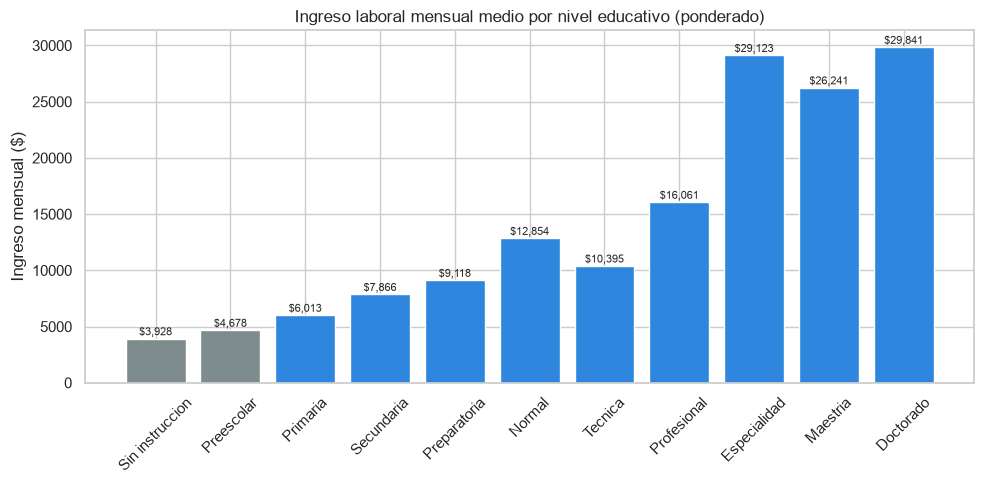

In [6]:
sns.set_theme(style="whitegrid")
ing = base.groupby("nivel_edu", observed=True).apply(media_pond, include_groups=False)
fig, ax = plt.subplots(figsize=(10, 5))
colores = ["#7f8c8d" if n in ["Sin instruccion", "Preescolar"] else "#2e86de" for n in ing.index]
ax.bar(ing.index, ing.values, color=colores)
ax.set_title("Ingreso laboral mensual medio por nivel educativo (ponderado)")
ax.set_ylabel("Ingreso mensual ($)")
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(ing.values):
    ax.text(i, v + 300, f"${v:,.0f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

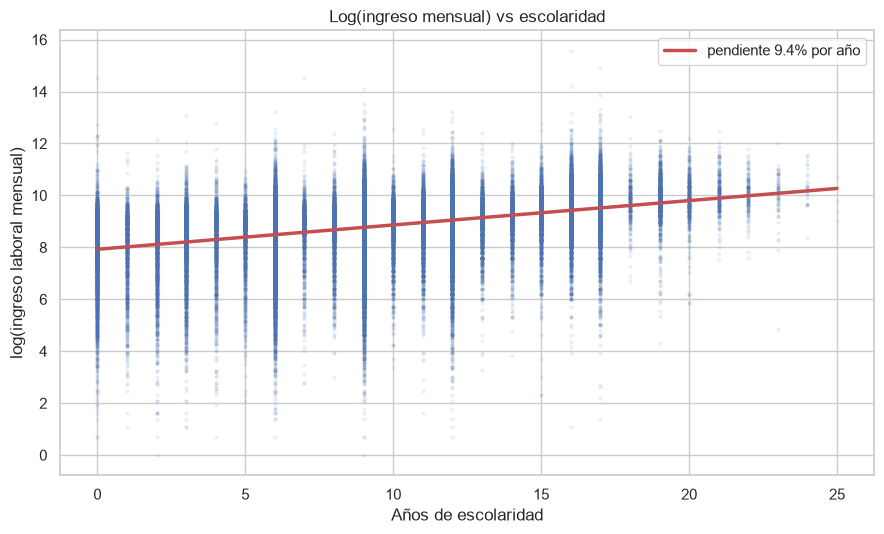

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
muestra = base[base["ing_lab_men"] > 0]
ax.scatter(muestra["escolaridad"], muestra["ln_ing_men"], s=4, alpha=0.08, color="#4C72B0")
p, i = np.polyfit(muestra["escolaridad"], muestra["ln_ing_men"], 1)
x = np.linspace(muestra["escolaridad"].min(), muestra["escolaridad"].max(), 100)
ax.plot(x, p * x + i, color="#C44E52", lw=2.5, label=f"pendiente {p * 100:.1f}% por año")
ax.set_title("Log(ingreso mensual) vs escolaridad")
ax.set_xlabel("Años de escolaridad")
ax.set_ylabel("log(ingreso laboral mensual)")
ax.legend()
plt.tight_layout()
plt.show()

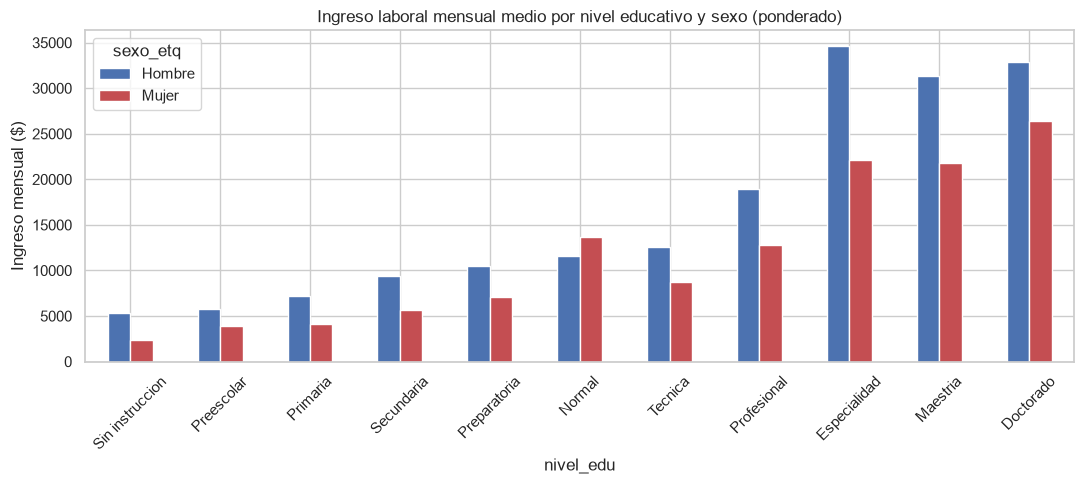

In [8]:
piv = base.pivot_table(index="nivel_edu", columns="sexo_etq", values="ing_lab_men",
                        aggfunc=media_pond, observed=True)
piv.plot(kind="bar", color=["#4C72B0", "#C44E52"], figsize=(11, 5))
plt.title("Ingreso laboral mensual medio por nivel educativo y sexo (ponderado)")
plt.ylabel("Ingreso mensual ($)")
plt.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 5. Econometría: ecuación de Mincer

$$\ln(ingreso_i) = \beta_0 + \beta_1 escolaridad_i + \beta_2 edad_i + \beta_3 edad_i^2 + \beta_4 mujer_i + \beta_5 \ln(horas_i) + u_i$$

Estimación por **mínimos cuadrados ponderados (WLS)** con el factor de expansión como peso y errores robustos (HC1). La muestra incluye ocupados de 14 años o más con ingreso laboral mensual positivo.

In [9]:
muestra = base[base["ing_lab_men"] > 0].copy()
X = sm.add_constant(muestra[["escolaridad", "edad", "edad2", "mujer", "ln_hrs"]])
m2 = sm.WLS(muestra["ln_ing_men"], X, weights=muestra["factor"]).fit(cov_type="HC1")
print(m2.summary().tables[1])

                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           4.4210      0.042    105.953      0.000       4.339       4.503
escolaridad     0.0930      0.001    109.431      0.000       0.091       0.095
edad            0.0570      0.001     39.246      0.000       0.054       0.060
edad2          -0.0006   1.79e-05    -35.412      0.000      -0.001      -0.001
mujer          -0.2918      0.007    -42.194      0.000      -0.305      -0.278
ln_hrs          0.6701      0.009     74.517      0.000       0.652       0.688


In [10]:
rend = m2.params["escolaridad"] * 100
brecha = (np.exp(m2.params["mujer"]) - 1) * 100
edad_max = -m2.params["edad"] / (2 * m2.params["edad2"])
print(f"Rendimiento de la educación: {rend:.2f}% por año de escolaridad")
print(f"Brecha de género: {brecha:.2f}%")
print(f"Edad de ingreso máximo estimado: {edad_max:.1f} años")
print(f"Elasticidad ingreso-horas: {m2.params['ln_hrs']:.3f}")

Rendimiento de la educación: 9.30% por año de escolaridad
Brecha de género: -25.31%
Edad de ingreso máximo estimado: 45.1 años
Elasticidad ingreso-horas: 0.670


In [11]:
X3 = sm.add_constant(muestra[["escolaridad", "edad", "edad2", "mujer"]])
m1 = sm.WLS(muestra["ln_ing_men"], X3, weights=muestra["factor"]).fit(cov_type="HC1")
print(f"Sin controlar horas, la brecha de género es {(np.exp(m1.params['mujer']) - 1) * 100:.2f}% "
      f"y el rendimiento educativo {m1.params['escolaridad'] * 100:.2f}%.")

Sin controlar horas, la brecha de género es -37.86% y el rendimiento educativo 9.46%.


## 6. Conclusiones

1. **H1 se confirma:** existe una relación positiva y marcada entre educación e ingresos. Cada año adicional de escolaridad se asocia con un incremento cercano al 9% del ingreso laboral mensual; un profesional gana ~300% más que alguien sin instrucción.
2. **H2 se confirma:** aun controlando por educación, edad y horas, las mujeres ganan ~25% menos que los hombres (la brecha baja a ~18% al comparar salario por hora).
3. **H3 se confirma:** el perfil ingreso-edad es cóncavo, con un máximo estimado alrededor de los 44 años.
4. Las horas trabajadas son un canal importante: su elasticidad es ~0.67 y explica parte de la brecha de género (las mujeres trabajan menos horas en promedio).

*Resultados descriptivos y econométricos completos en `informe.md` y `salida/`.*